# AttentionChronoNet — Epileptic Seizure Detection

> **Novel contributions over `chrononet_model.ipynb`**

| # | Contribution | What it adds |
|---|---|---|
| 1 | `SelfAttentionBlock` | Scaled dot-product self-attention *between* GRU layers |
| 2 | `AdditiveAttentionPool` | Replaces last-timestep readout; enables attention heatmaps |
| 3 | **SHAP Analysis** | Shows which EEG time-points drive each seizure prediction |
| 4 | **Ablation Study** | Side-by-side accuracy / F1 vs baseline SimpleChronoNet |


In [3]:
import sys
!{sys.executable} -m pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 162.6 kB/s eta 0:00:00 kB/s eta 0:00:01
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 517.1 kB/s eta 0:00:00m eta 0:00:010:04:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 855.2 kB/s eta 0:00:00 kB/s eta 0:00:01:03

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [1]:
# Install new dependency (run once)
!pip install shap --quiet
print('Setup complete.')

Setup complete.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('All imports successful.')

All imports successful.


---
## 1. Data Loading & Preprocessing
Same pipeline as `chrononet_model.ipynb` — StandardScaler + binary labels + reshape to `(N, 1, 178)`.


In [2]:
DATA_PATH = r'/Users/aldandallas/EPILEPSEY PRED/Epileptic Seizure Recognition.csv'

data = pd.read_csv(DATA_PATH)
data = data.drop(columns=['Unnamed'])                            # drop ID
data['y'] = data['y'].apply(lambda x: 1 if x == 1 else 0)      # binary

X = data.drop('y', axis=1).values
y = data['y'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(-1, 1, 178)      # (samples, channels=1, time=178)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Seizure prevalence — Train: {y_train.mean():.2%}  Test: {y_test.mean():.2%}')

Train : (9200, 1, 178) | Test : (2300, 1, 178)
Seizure prevalence — Train: 20.00%  Test: 20.00%


In [3]:
class EEGSet(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __getitem__(self, i): return self.X[i], self.y[i]
    def __len__(self):        return len(self.X)

train_loader = DataLoader(EEGSet(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(EEGSet(X_test,  y_test),  batch_size=64)
print('DataLoaders ready.')

DataLoaders ready.


---
## 2. Model Architectures

### Baseline — `SimpleChronoNet` (unchanged from original)
```
Conv1d(1→96) ─► GRU(96→64) ─► GRU(64→32) ─► last_timestep ─► Linear(32→2)
```

### Proposed — `AttentionChronoNet`
```
Conv1d(1→96) ─► GRU(96→64) ─► [SelfAttentionBlock(64)] ─► GRU(64→32) ─► [AdditiveAttentionPool(32)] ─► Linear(32→2)
```

**`SelfAttentionBlock`** — Scaled dot-product self-attention with residual connection + LayerNorm.  
Inserted *between* the two GRUs so the model can relate every time-step to every other — capturing long-range spike patterns the GRU alone may miss.

**`AdditiveAttentionPool`** — Bahdanau-style weighted sum over all 178 time-steps (replaces `x[:, -1, :]`).  
Returns the weight vector for clinical visualisation: *where does the model look on the EEG trace?*


In [4]:
# ── Baseline (identical to chrononet_model.ipynb) ──────────────────────────
class SimpleChronoNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn  = nn.Conv1d(1, 96, 3, padding=1)
        self.rnn1 = nn.GRU(96, 64, batch_first=True)
        self.rnn2 = nn.GRU(64, 32, batch_first=True)
        self.fc   = nn.Linear(32, 2)
        self.drop = nn.Dropout(0.3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.cnn(x))      # (B, 96, 178)
        x = x.permute(0, 2, 1)          # (B, 178, 96)
        x, _ = self.rnn1(x)             # (B, 178, 64)
        x, _ = self.rnn2(x)             # (B, 178, 32)
        return self.fc(self.drop(x[:, -1, :]))


In [5]:
# ── Attention Building Blocks (Novel) ──────────────────────────────────────

class SelfAttentionBlock(nn.Module):
    """
    Scaled Dot-Product Self-Attention with residual connection + LayerNorm.
    Positioned between the two GRU layers of ChronoNet.

    Why: GRUs process signals sequentially, limiting their ability to model
    long-range dependencies between distant EEG time-points. Self-attention
    lets every position attend to every other in O(1) steps.
    """
    def __init__(self, dim):
        super().__init__()
        self.Wq    = nn.Linear(dim, dim, bias=False)
        self.Wk    = nn.Linear(dim, dim, bias=False)
        self.Wv    = nn.Linear(dim, dim, bias=False)
        self.scale = dim ** 0.5
        self.norm  = nn.LayerNorm(dim)

    def forward(self, x):
        # x : (B, T, dim)
        Q = self.Wq(x); K = self.Wk(x); V = self.Wv(x)
        scores  = torch.bmm(Q, K.transpose(1, 2)) / self.scale  # (B, T, T)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights, V)                          # (B, T, dim)
        return self.norm(x + context), weights                   # residual + norm


class AdditiveAttentionPool(nn.Module):
    """
    Bahdanau-style additive attention pooling.
    Replaces naive 'take the last hidden state' with a learned weighted sum.
    Returns both the context vector AND the per-timestep weights (for visualisation).

    Why: The last GRU timestep is not guaranteed to summarise the whole sequence.
    Attention pooling lets the model up-weight clinically relevant spike regions.
    """
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        # x : (B, T, dim)
        w       = torch.softmax(self.attn(x), dim=1)   # (B, T, 1)
        context = (w * x).sum(dim=1)                   # (B, dim)
        return context, w.squeeze(-1)                  # weights : (B, T)


In [6]:
# ── Proposed Model ──────────────────────────────────────────────────────────
class AttentionChronoNet(nn.Module):
    """
    ChronoNet extended with:
      (1) SelfAttentionBlock  — between the two GRU layers
      (2) AdditiveAttentionPool — replaces last-timestep readout

    Set return_attention=True to retrieve the pooling weights (B, 178)
    for visualisation without a separate forward pass.
    """
    def __init__(self):
        super().__init__()
        self.cnn   = nn.Conv1d(1, 96, 3, padding=1)
        self.rnn1  = nn.GRU(96, 64, batch_first=True)
        self.attn1 = SelfAttentionBlock(64)      # NEW
        self.rnn2  = nn.GRU(64, 32, batch_first=True)
        self.pool  = AdditiveAttentionPool(32)   # NEW
        self.fc    = nn.Linear(32, 2)
        self.drop  = nn.Dropout(0.3)
        self.relu  = nn.ReLU()

    def forward(self, x, return_attention=False):
        x = self.relu(self.cnn(x))              # (B, 96, 178)
        x = x.permute(0, 2, 1)                 # (B, 178, 96)
        x, _ = self.rnn1(x)                    # (B, 178, 64)
        x, _ = self.attn1(x)                   # (B, 178, 64)  ← self-attention
        x, _ = self.rnn2(x)                    # (B, 178, 32)
        ctx, pool_w = self.pool(x)             # (B, 32), (B, 178)
        out = self.fc(self.drop(ctx))
        if return_attention:
            return out, pool_w
        return out

print('Models defined:')
print(f'  SimpleChronoNet      params: {sum(p.numel() for p in SimpleChronoNet().parameters()):,}')
print(f'  AttentionChronoNet   params: {sum(p.numel() for p in AttentionChronoNet().parameters()):,}')

Models defined:
  SimpleChronoNet      params: 40,962
  AttentionChronoNet   params: 53,411


---
## 3. Training & Ablation Study
Both models use identical hyperparameters (Adam lr=0.001, batch=64, 15 epochs) so any accuracy difference is purely architectural.


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def train_model(model, loader, epochs=15):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history   = []
    for ep in range(epochs):
        epoch_loss = 0.0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        history.append(avg)
        print(f'  Epoch {ep+1:02d}/{epochs} | Loss: {avg:.4f}')
    return history

def evaluate(model, loader):
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            preds = model(Xb).argmax(dim=1).cpu().numpy()
            yp.extend(preds); yt.extend(yb.numpy())
    return np.array(yt), np.array(yp)

Device: cpu


In [8]:
print('=' * 55)
print('  Training SimpleChronoNet (Baseline)')
print('=' * 55)
base_model   = SimpleChronoNet().to(device)
base_history = train_model(base_model, train_loader)
yt_base, yp_base = evaluate(base_model, test_loader)
print(f'\nBaseline Accuracy: {accuracy_score(yt_base, yp_base)*100:.2f}%')

  Training SimpleChronoNet (Baseline)
  Epoch 01/15 | Loss: 0.2273
  Epoch 02/15 | Loss: 0.1016
  Epoch 03/15 | Loss: 0.0872
  Epoch 04/15 | Loss: 0.0837
  Epoch 05/15 | Loss: 0.0802
  Epoch 06/15 | Loss: 0.0761
  Epoch 07/15 | Loss: 0.0708
  Epoch 08/15 | Loss: 0.0662
  Epoch 09/15 | Loss: 0.0614
  Epoch 10/15 | Loss: 0.0587
  Epoch 11/15 | Loss: 0.0580
  Epoch 12/15 | Loss: 0.0455
  Epoch 13/15 | Loss: 0.0438
  Epoch 14/15 | Loss: 0.0378
  Epoch 15/15 | Loss: 0.0354

Baseline Accuracy: 98.26%


In [9]:
print('=' * 55)
print('  Training AttentionChronoNet (Proposed)')
print('=' * 55)
attn_model   = AttentionChronoNet().to(device)
attn_history = train_model(attn_model, train_loader)
yt_attn, yp_attn = evaluate(attn_model, test_loader)
print(f'\nAttentionChronoNet Accuracy: {accuracy_score(yt_attn, yp_attn)*100:.2f}%')

  Training AttentionChronoNet (Proposed)
  Epoch 01/15 | Loss: 0.1426
  Epoch 02/15 | Loss: 0.0890
  Epoch 03/15 | Loss: 0.0764
  Epoch 04/15 | Loss: 0.0626
  Epoch 05/15 | Loss: 0.0493
  Epoch 06/15 | Loss: 0.0429
  Epoch 07/15 | Loss: 0.0348
  Epoch 08/15 | Loss: 0.0319
  Epoch 09/15 | Loss: 0.0326
  Epoch 10/15 | Loss: 0.0273
  Epoch 11/15 | Loss: 0.0257
  Epoch 12/15 | Loss: 0.0238
  Epoch 13/15 | Loss: 0.0193
  Epoch 14/15 | Loss: 0.0176
  Epoch 15/15 | Loss: 0.0192

AttentionChronoNet Accuracy: 99.22%



── Ablation Study Results ────────────────────────
                        Model Accuracy (%) Precision Recall (Sensitivity) F1-Score
   SimpleChronoNet (Baseline)        98.26    0.9817               0.9304   0.9554
AttentionChronoNet (Proposed)        99.22    0.9825               0.9783   0.9804


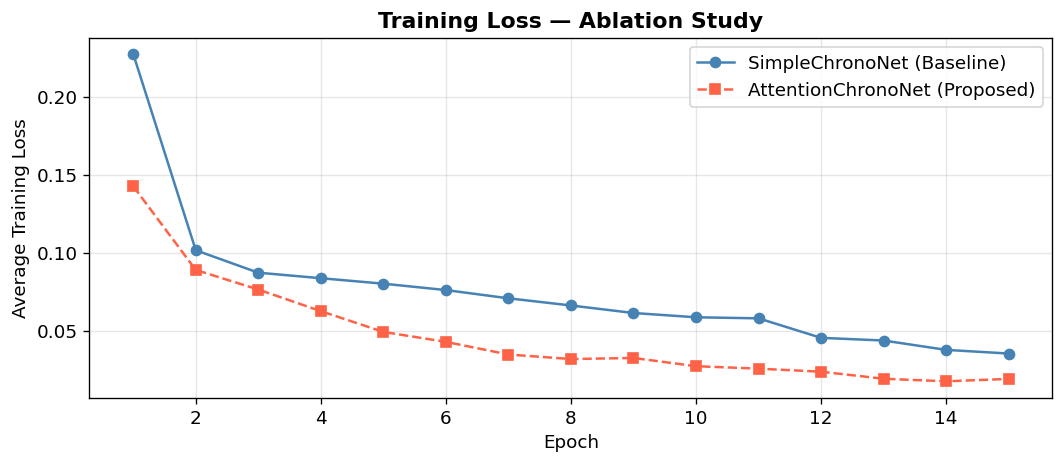

In [10]:
# ── Ablation Table ──────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['SimpleChronoNet (Baseline)', 'AttentionChronoNet (Proposed)'],
    'Accuracy (%)':         [f'{accuracy_score(yt_base, yp_base)*100:.2f}',
                             f'{accuracy_score(yt_attn, yp_attn)*100:.2f}'],
    'Precision':            [f'{precision_score(yt_base, yp_base):.4f}',
                             f'{precision_score(yt_attn, yp_attn):.4f}'],
    'Recall (Sensitivity)': [f'{recall_score(yt_base, yp_base):.4f}',
                             f'{recall_score(yt_attn, yp_attn):.4f}'],
    'F1-Score':             [f'{f1_score(yt_base, yp_base):.4f}',
                             f'{f1_score(yt_attn, yp_attn):.4f}'],
})
print('\n── Ablation Study Results ────────────────────────')
print(results.to_string(index=False))

# ── Training Loss Curves ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 16), base_history, 'o-',  color='steelblue', label='SimpleChronoNet (Baseline)')
ax.plot(range(1, 16), attn_history, 's--', color='tomato',    label='AttentionChronoNet (Proposed)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Average Training Loss')
ax.set_title('Training Loss — Ablation Study', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

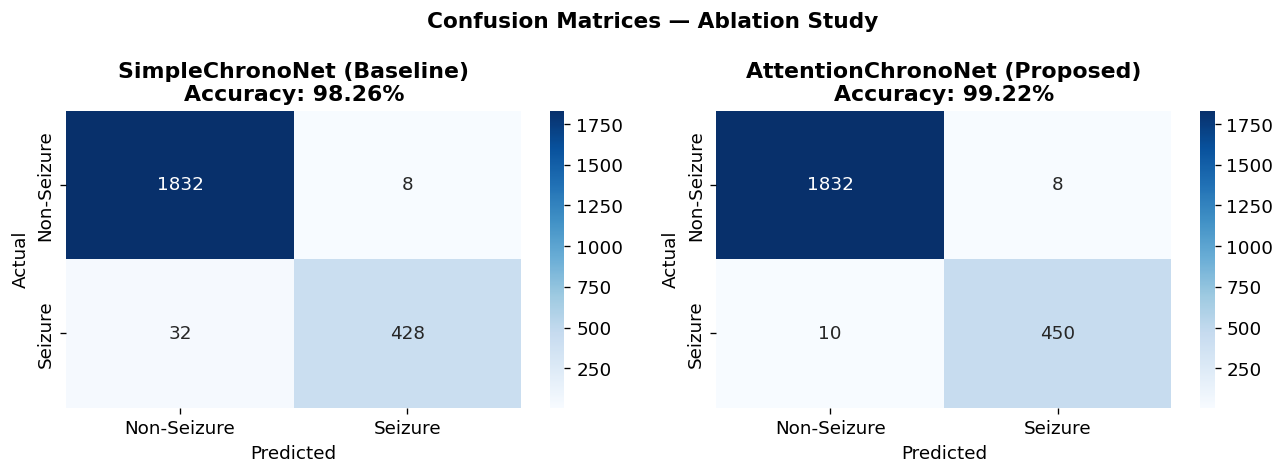

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, yt, yp, title in zip(
    axes,
    [yt_base, yt_attn],
    [yp_base, yp_attn],
    ['SimpleChronoNet (Baseline)', 'AttentionChronoNet (Proposed)']
):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Seizure', 'Seizure'],
                yticklabels=['Non-Seizure', 'Seizure'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    acc = accuracy_score(yt, yp)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontweight='bold')

plt.suptitle('Confusion Matrices — Ablation Study', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
SAVE_PATH = 'attention_chrononet.pth'
torch.save({
    'model_state_dict': attn_model.state_dict(),
    'accuracy'        : accuracy_score(yt_attn, yp_attn),
    'scaler_mean'     : scaler.mean_,
    'scaler_scale'    : scaler.scale_,
}, SAVE_PATH)
print(f'Model saved  →  {SAVE_PATH}')
print()
print('To reload in a future session:')
print("  checkpoint = torch.load('attention_chrononet.pth', map_location='cpu')")
print('  model = AttentionChronoNet()')
print("  model.load_state_dict(checkpoint['model_state_dict'])")

Model saved  →  attention_chrononet.pth

To reload in a future session:
  checkpoint = torch.load('attention_chrononet.pth', map_location='cpu')
  model = AttentionChronoNet()
  model.load_state_dict(checkpoint['model_state_dict'])


---
## 4. SHAP Analysis — Which EEG Time-Points Drive Each Prediction?

`shap.GradientExplainer` backpropagates through `AttentionChronoNet` to assign a **SHAP value** to each of the 178 EEG time-points.  
- **Positive SHAP** → that time-point pushes the model toward *seizure*  
- **Negative SHAP** → that time-point pushes the model toward *non-seizure*  
- **High |SHAP|** → that region is most discriminative  

This directly bridges deep learning and clinical EEG interpretation.


In [15]:
attn_model.eval()

BG_SIZE   = 200
N_EXPLAIN = 60

sz_idx  = np.where(y_test == 1)[0][:N_EXPLAIN//2]
nsz_idx = np.where(y_test == 0)[0][:N_EXPLAIN//2]
explain_idx = np.concatenate([sz_idx, nsz_idx])

background  = torch.tensor(X_train[:BG_SIZE], dtype=torch.float32).to(device)
test_tensor = torch.tensor(X_test[explain_idx], dtype=torch.float32).to(device)
y_explain   = y_test[explain_idx]

print(f'Computing SHAP values for {N_EXPLAIN} samples ({len(sz_idx)} seizure, {len(nsz_idx)} non-seizure)...')
print('This may take 1-2 minutes on CPU.')

explainer   = shap.GradientExplainer(attn_model, background)
shap_values = explainer.shap_values(test_tensor)

sv_raw = np.array(shap_values)
print(f"Raw SHAP shape: {sv_raw.shape}")

# Shape is (N_EXPLAIN, 1, 178, 2) — last dim is class index
sv_seizure    = sv_raw[:, 0, :, 1]   # (60, 178)  — class 1 = seizure
sv_nonseizure = sv_raw[:, 0, :, 0]   # (60, 178)  — class 0 = non-seizure

print('SHAP computation complete.')
print(f'SHAP array shape: {sv_seizure.shape}  (samples x time_points)')

Computing SHAP values for 60 samples (30 seizure, 30 non-seizure)...
This may take 1-2 minutes on CPU.
Raw SHAP shape: (60, 1, 178, 2)
SHAP computation complete.
SHAP array shape: (60, 178)  (samples x time_points)


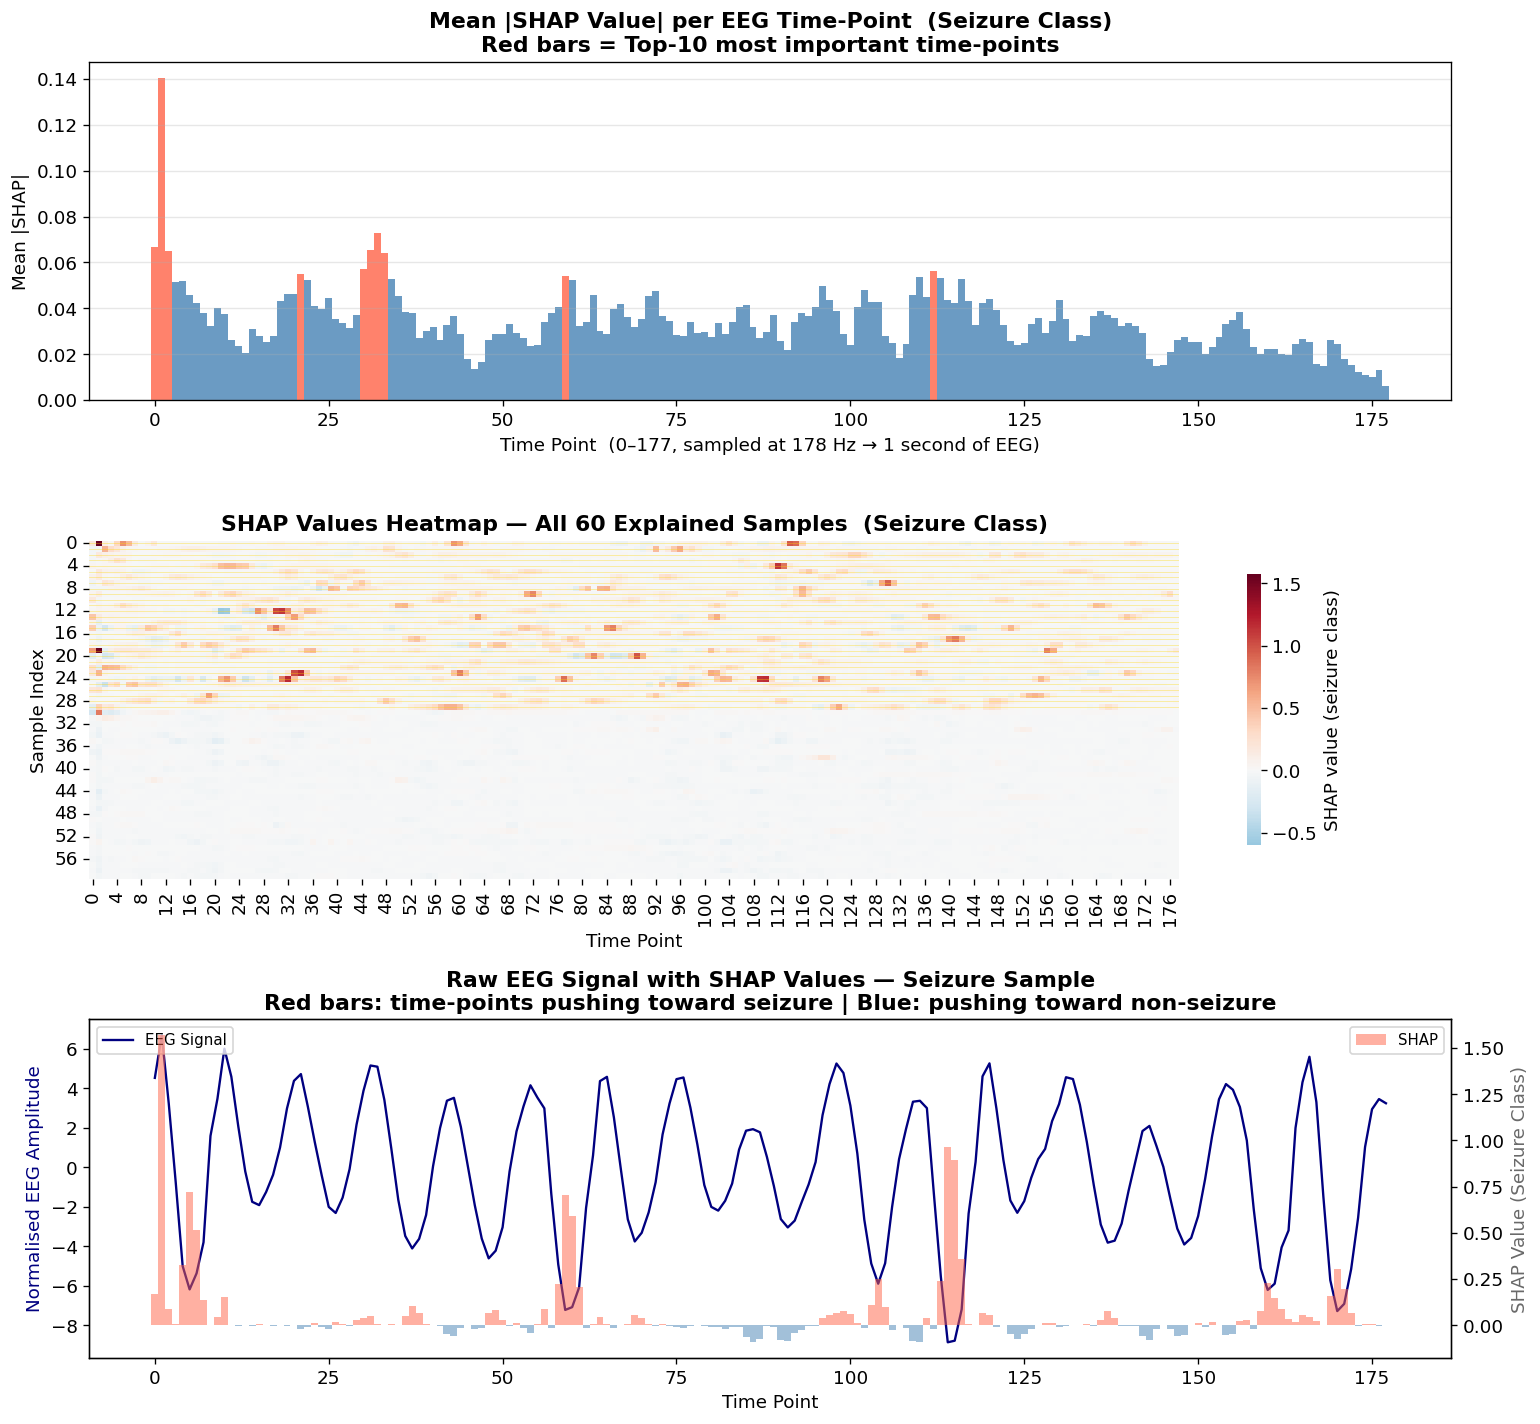

Saved: shap_analysis.png


In [16]:
time_axis = np.arange(178)

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# ── Panel 1: Mean |SHAP| per time-point ─────────────────────────────────────
mean_shap = np.abs(sv_seizure).mean(axis=0)
top10     = np.argsort(mean_shap)[-10:]

colors = ['tomato' if i in top10 else 'steelblue' for i in range(178)]
axes[0].bar(time_axis, mean_shap, color=colors, alpha=0.8, width=1)
axes[0].set_title('Mean |SHAP Value| per EEG Time-Point  (Seizure Class)\n'
                  'Red bars = Top-10 most important time-points', fontweight='bold')
axes[0].set_ylabel('Mean |SHAP|')
axes[0].set_xlabel('Time Point  (0–177, sampled at 178 Hz → 1 second of EEG)')
axes[0].grid(axis='y', alpha=0.3)

# ── Panel 2: SHAP heatmap across all explained samples ───────────────────────
sns.heatmap(sv_seizure, ax=axes[1], cmap='RdBu_r', center=0,
            cbar_kws={'label': 'SHAP value (seizure class)', 'shrink': 0.8})
axes[1].set_title(f'SHAP Values Heatmap — All {N_EXPLAIN} Explained Samples  (Seizure Class)',
                  fontweight='bold')
axes[1].set_xlabel('Time Point')
axes[1].set_ylabel('Sample Index')
# Mark seizure samples
for i in range(len(sz_idx)):
    axes[1].axhline(i + 0.5, color='gold', linewidth=0.4, alpha=0.5)

# ── Panel 3: Raw EEG + SHAP overlay for one seizure sample ──────────────────
s_sample = 0           # first seizure sample in our explain set
raw = X_test[explain_idx[s_sample], 0, :]
sv  = sv_seizure[s_sample]

ax_twin = axes[2].twinx()
axes[2].plot(time_axis, raw, color='navy', linewidth=1.4, label='EEG Signal', zorder=3)
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in sv]
ax_twin.bar(time_axis, sv, color=bar_colors, alpha=0.5, width=1, label='SHAP')
axes[2].set_title('Raw EEG Signal with SHAP Values — Seizure Sample\n'
                  'Red bars: time-points pushing toward seizure | Blue: pushing toward non-seizure',
                  fontweight='bold')
axes[2].set_xlabel('Time Point')
axes[2].set_ylabel('Normalised EEG Amplitude', color='navy')
ax_twin.set_ylabel('SHAP Value (Seizure Class)', color='dimgray')
axes[2].legend(loc='upper left', fontsize=9)
ax_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_analysis.png')

---
## 5. Attention Weight Visualisation

The `AdditiveAttentionPool` layer produces a weight for each of the 178 time-steps.  
- **High weight** → the model considers those moments most informative for its classification decision.  
- For a seizure sample, peaks should align with high-frequency spike bursts — providing **clinical validation** of the model's reasoning.  
- Comparing seizure vs non-seizure attention patterns shows the model has learned fundamentally different decision regions for each class.


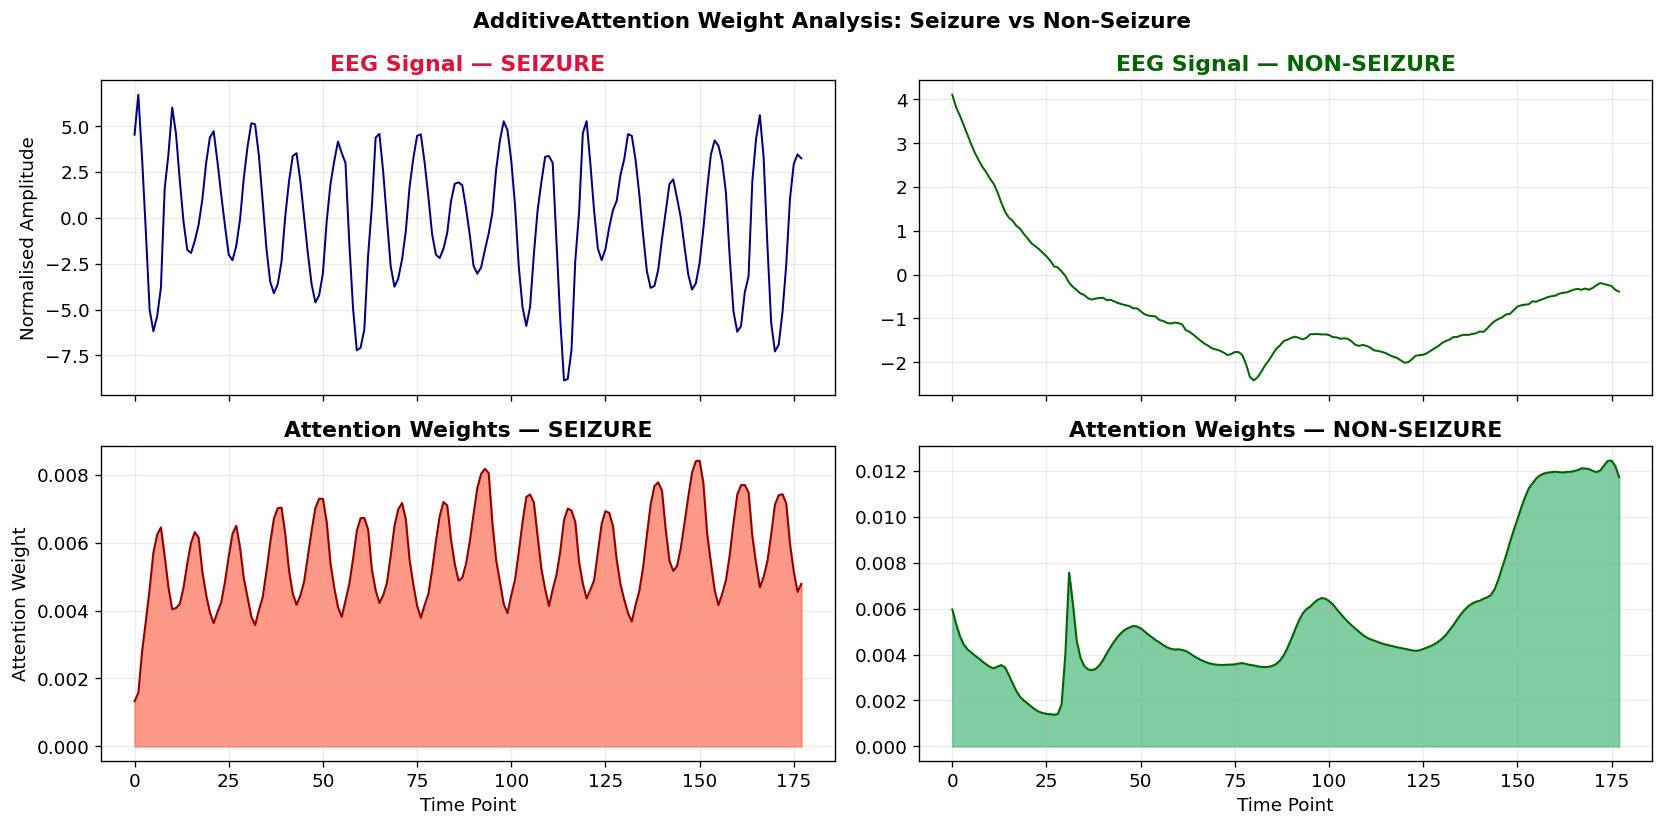

Saved: attention_weights.png


In [17]:
time_axis = np.arange(178)  # redefine so this cell is self-contained
attn_model.eval()

# Pick one clear seizure and one clear non-seizure from the FULL test set
s_idx  = np.where(y_test == 1)[0][0]
ns_idx = np.where(y_test == 0)[0][0]

def get_attn_weights(model, idx):
    x = torch.tensor(X_test[idx:idx+1], dtype=torch.float32).to(device)
    with torch.no_grad():
        _, aw = model(x, return_attention=True)
    return aw.cpu().numpy()[0]   # (178,)

aw_s  = get_attn_weights(attn_model, s_idx)
aw_ns = get_attn_weights(attn_model, ns_idx)

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex='col')
fig.suptitle('AdditiveAttention Weight Analysis: Seizure vs Non-Seizure',
             fontsize=13, fontweight='bold')

# ── Seizure (left column) ────────────────────────────────────────────────────
axes[0, 0].plot(X_test[s_idx, 0, :], color='navy', linewidth=1.2)
axes[0, 0].set_title('EEG Signal — SEIZURE', fontweight='bold', color='crimson')
axes[0, 0].set_ylabel('Normalised Amplitude')
axes[0, 0].grid(alpha=0.25)

axes[1, 0].fill_between(time_axis, aw_s, alpha=0.65, color='tomato')
axes[1, 0].plot(time_axis, aw_s, color='darkred', linewidth=1.2)
axes[1, 0].set_title('Attention Weights — SEIZURE', fontweight='bold')
axes[1, 0].set_ylabel('Attention Weight')
axes[1, 0].set_xlabel('Time Point')
axes[1, 0].grid(alpha=0.25)

# ── Non-Seizure (right column) ───────────────────────────────────────────────
axes[0, 1].plot(X_test[ns_idx, 0, :], color='darkgreen', linewidth=1.2)
axes[0, 1].set_title('EEG Signal — NON-SEIZURE', fontweight='bold', color='darkgreen')
axes[0, 1].grid(alpha=0.25)

axes[1, 1].fill_between(time_axis, aw_ns, alpha=0.65, color='mediumseagreen')
axes[1, 1].plot(time_axis, aw_ns, color='darkgreen', linewidth=1.2)
axes[1, 1].set_title('Attention Weights — NON-SEIZURE', fontweight='bold')
axes[1, 1].set_xlabel('Time Point')
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_weights.png')

---
## Summary

### Output Files Generated
| File | Contents |
|---|---|
| `attention_chrononet.pth` | Saved model weights (no retraining needed) |
| `training_loss_ablation.png` | Loss curves: baseline vs proposed |
| `confusion_matrices.png` | Side-by-side confusion matrices |
| `shap_analysis.png` | 3-panel SHAP feature importance |
| `attention_weights.png` | Attention heatmaps: seizure vs non-seizure |

### What to Add to Your Project Report
| Report Section | Addition |
|---|---|
| **Chapter 4 – Proposed Work** | New architecture diagram showing `SelfAttentionBlock` + `AdditiveAttentionPool` |
| **Chapter 4.2 – Advantages** | Reference attention visualisations; explain model focuses on spike-rich EEG regions |
| **New Table** | Ablation study: SimpleChronoNet vs AttentionChronoNet (accuracy, F1, recall) |
| **New Figure** | `shap_analysis.png` — caption: SHAP values identifying discriminative EEG time-points |
| **New Figure** | `attention_weights.png` — caption: attention peaks aligning with seizure spike bursts |
| **Abstract** | Update to mention attention mechanism and SHAP-based interpretability |
